In [1]:
!pip install -q python-dotenv transformers datasets scikit-learn torch gensim sentencepiece

import os
import sys
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score


from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/NLP'
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)

from data.data_processor import DataProcessor
from data.dataset import FoodDataset
from models.dual_trainer import DualModelTrainer
from evaluation.post_processor import ModelPostProcessor
from evaluation.create_confusion_matrix import ConfusionMatrixCreator

load_dotenv(os.path.join(PROJECT_PATH, '.env'))
hf_token = os.getenv('HF_TOKEN')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Χρήση συσκευής: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.9 MB/s eta 0:00:00
Mounted at /content/drive
Χρήση συσκευής: cuda


In [2]:
processor = DataProcessor()
data = processor.process_data(
    train_path='csv/train.csv',
    val_path='csv/valid.csv',
    test_path='csv/test.csv',
    tokenize=False
)

train_df = data['train_df']
val_df   = data['val_df']
test_df  = data['test_df']

hazard_weights = compute_class_weight('balanced', classes=np.unique(train_df['hazard_label']), y=train_df['hazard_label'].values)
product_weights = compute_class_weight('balanced', classes=np.unique(train_df['product_label']), y=train_df['product_label'].values)

tensor_hazard_weights = torch.tensor(hazard_weights, dtype=torch.float32).to(device)
tensor_product_weights = torch.tensor(product_weights, dtype=torch.float32).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"macro_f1": f1_score(labels, predictions, average='macro')}

LOCAL_TEMP_DIR = "/content/temp_models"
os.makedirs(LOCAL_TEMP_DIR, exist_ok=True)

In [3]:
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = FoodDataset(train_df['clean_text'], train_df['hazard_label'], train_df['product_label'], tokenizer)
val_dataset = FoodDataset(val_df['clean_text'], val_df['hazard_label'], val_df['product_label'], tokenizer)

dummy_test_labels = pd.Series([0] * len(test_df))
test_dataset = FoodDataset(test_df['clean_text'], dummy_test_labels, dummy_test_labels, tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:
#HAZARD
model_hazard = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=10).to(device)

args_hazard = TrainingArguments(
    output_dir=f"{LOCAL_TEMP_DIR}/res_rob_haz", eval_strategy="epoch", save_strategy="epoch",
    learning_rate=1.5e-5, warmup_ratio=0.1, lr_scheduler_type="cosine", # Ειδικά tuned για RoBERTa!
    per_device_train_batch_size=16, per_device_eval_batch_size=16,
    num_train_epochs=15, load_best_model_at_end=True, metric_for_best_model="macro_f1",
    remove_unused_columns=False, label_names=['hazard_label'], save_total_limit=1
)

trainer_hazard = DualModelTrainer(
    target_column='hazard_label', class_weights=tensor_hazard_weights,
    model=model_hazard, args=args_hazard,
    train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics
)
trainer_hazard.train()

rob_hazard_test_probs = F.softmax(torch.tensor(trainer_hazard.predict(test_dataset).predictions), dim=-1).numpy()
rob_hazard_val_probs = F.softmax(torch.tensor(trainer_hazard.predict(val_dataset).predictions), dim=-1).numpy()

preds_hazard_test = np.argmax(rob_hazard_test_probs, axis=-1)
preds_hazard_val = np.argmax(rob_hazard_val_probs, axis=-1)

del model_hazard, trainer_hazard
torch.cuda.empty_cache()
gc.collect()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,1.261691,0.443100
2,1.639819,0.843331,0.627377
3,1.639819,0.872123,0.800494
4,0.622437,0.669334,0.819108
5,0.378114,0.596269,0.869865
6,0.378114,0.833698,0.868044
7,0.288638,0.720462,0.786045
8,0.182179,0.842487,0.887527
9,0.182179,0.923305,0.813031
10,0.137894,0.947205,0.850263


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

547

In [7]:
#PRODUCT
model_product = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=22).to(device)

args_product = TrainingArguments(
    output_dir=f"{LOCAL_TEMP_DIR}/res_rob_prod", eval_strategy="epoch", save_strategy="epoch",
    learning_rate=1.5e-5, warmup_ratio=0.1, lr_scheduler_type="cosine", # Ειδικά tuned για RoBERTa!
    per_device_train_batch_size=16, per_device_eval_batch_size=16,
    num_train_epochs=15, load_best_model_at_end=True, metric_for_best_model="macro_f1",
    remove_unused_columns=False, label_names=['product_label'], save_total_limit=1
)

trainer_product = DualModelTrainer(
    target_column='product_label', class_weights=tensor_product_weights,
    model=model_product, args=args_product,
    train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics
)
trainer_product.train()

rob_product_test_probs = F.softmax(torch.tensor(trainer_product.predict(test_dataset).predictions), dim=-1).numpy()
rob_product_val_probs = F.softmax(torch.tensor(trainer_product.predict(val_dataset).predictions), dim=-1).numpy()

preds_product_test = np.argmax(rob_product_test_probs, axis=-1)
preds_product_val = np.argmax(rob_product_val_probs, axis=-1)

del model_product, trainer_product
torch.cuda.empty_cache()
gc.collect()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,2.388792,0.287591
2,2.617761,1.230211,0.581349
3,2.617761,1.060340,0.639335
4,1.198824,1.033610,0.677602
5,0.701204,1.066699,0.676677
6,0.701204,1.088727,0.662275
7,0.437819,1.142984,0.700150
8,0.281640,1.255096,0.701457
9,0.281640,1.338703,0.712993
10,0.175004,1.323852,0.704502


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

568

In [8]:
post_processor_rob = ModelPostProcessor(
    model_prefix="roberta",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    data_dict=data
)

post_processor_rob.save_probabilities(
    haz_val_probs=rob_hazard_val_probs,
    haz_test_probs=rob_hazard_test_probs,
    prod_val_probs=rob_product_val_probs,
    prod_test_probs=rob_product_test_probs
)

post_processor_rob.evaluate_and_export(
    preds_haz_val=preds_hazard_val,
    preds_prod_val=preds_product_val,
    preds_haz_test=preds_hazard_test,
    preds_prod_test=preds_product_test
)

ST1 SCORE (Validation): 0.7733
Hazard F1: 0.8875 | Product F1: 0.6591
Το αρχείο 'csv/roberta_submission.csv' δημιουργήθηκε επιτυχώς (997 γραμμές).


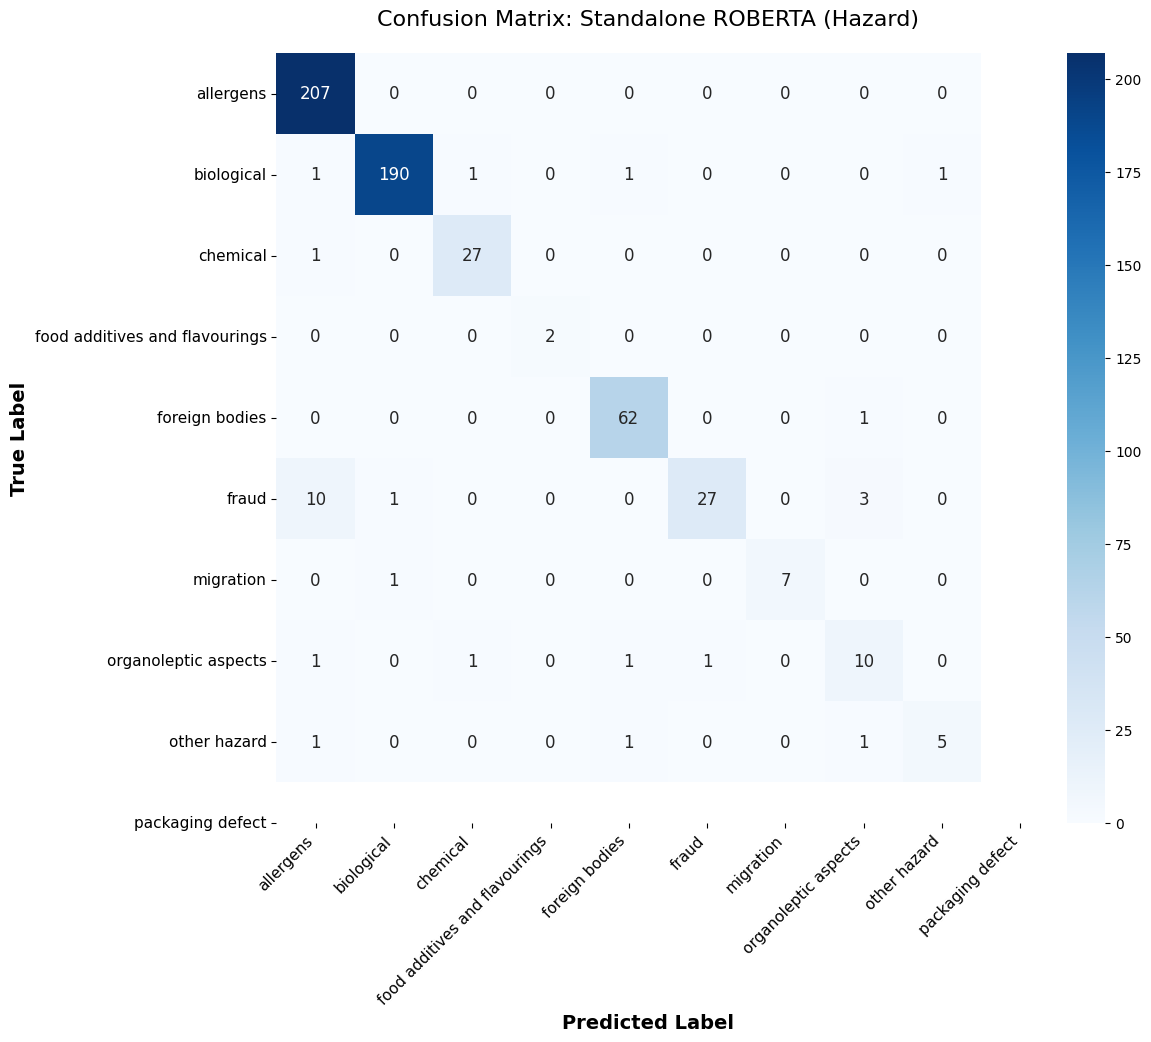

In [9]:
post_processor_rob.plot_hazard_confusion_matrix(preds_haz_val=preds_hazard_val)

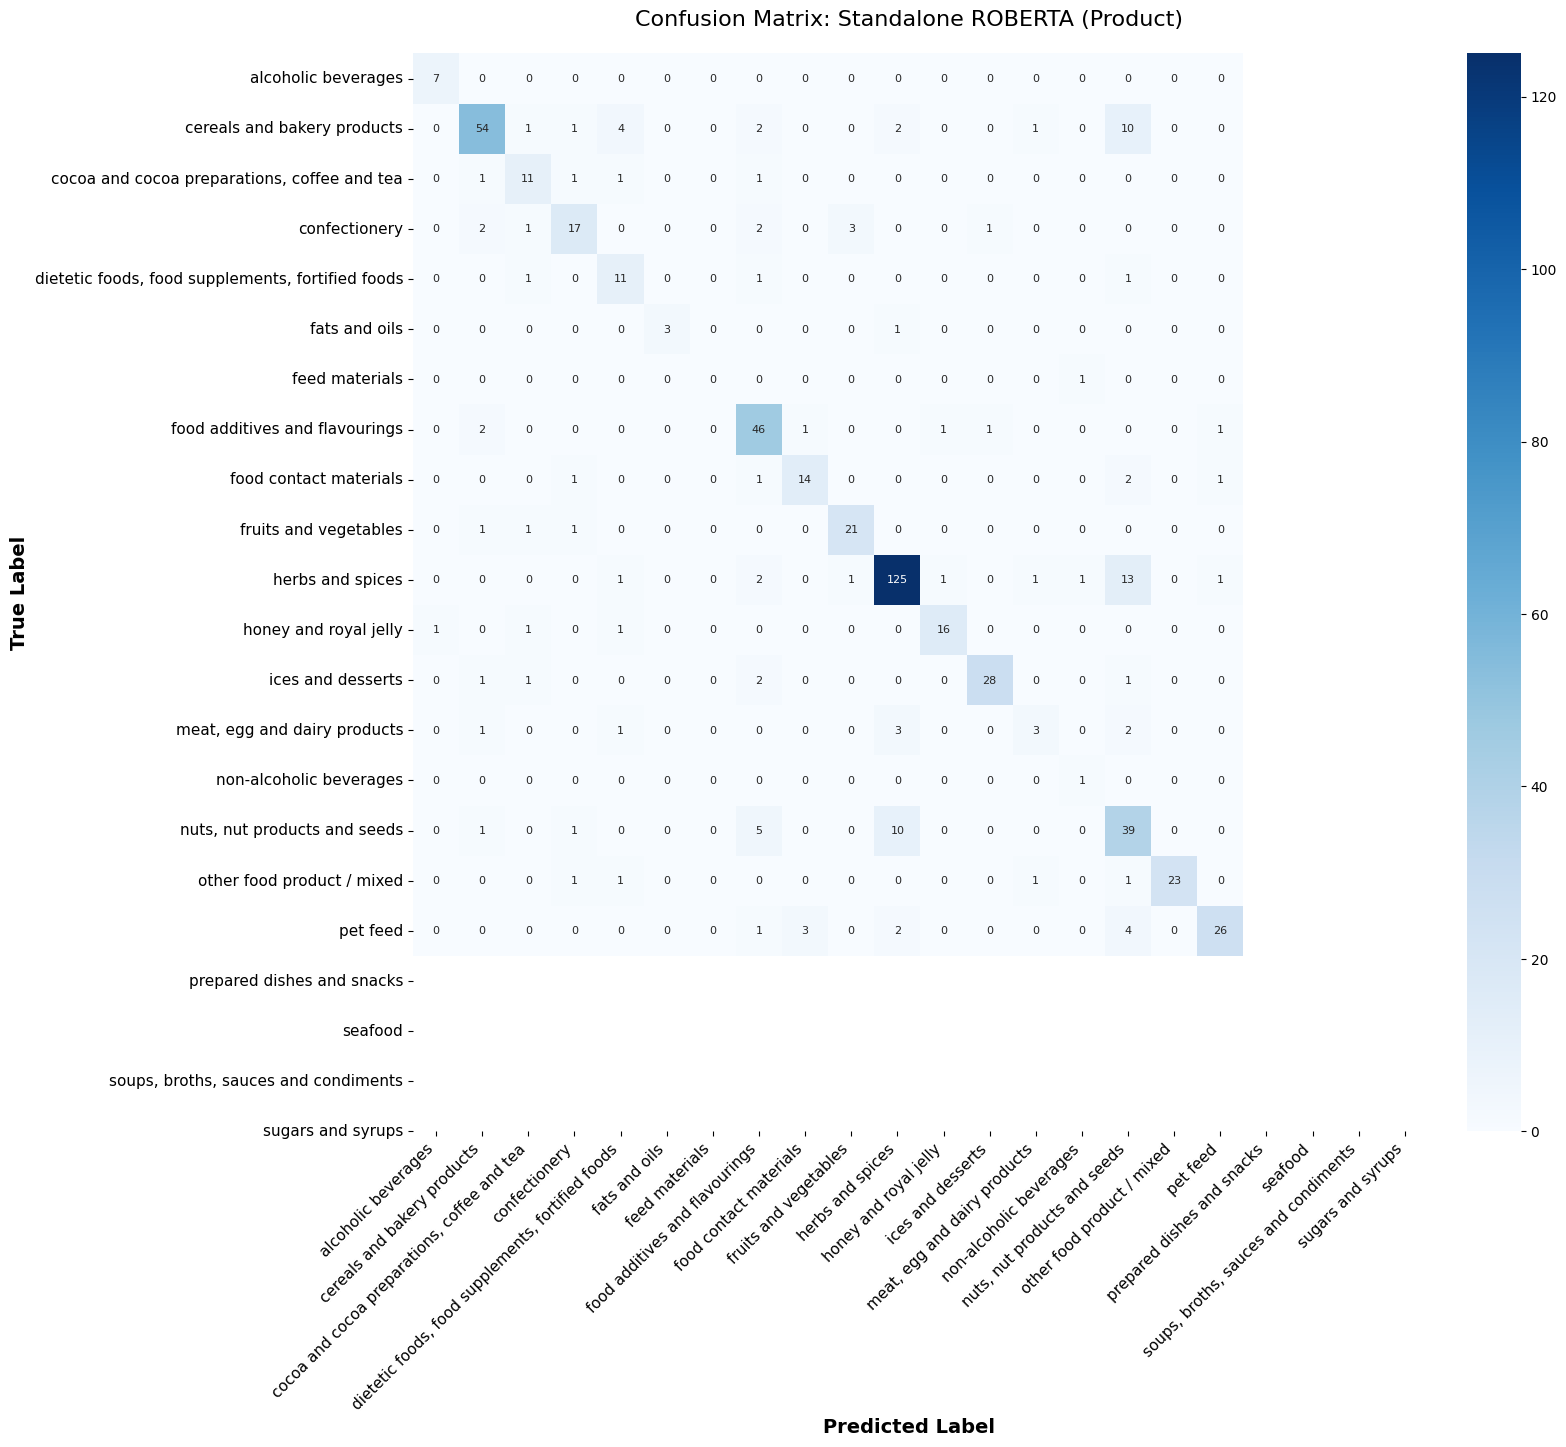

In [10]:
post_processor_rob.plot_product_confusion_matrix(preds_prod_val=preds_product_val)